In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
import pandas as pd
from keras.models import Sequential
from keras.layers import LSTM, Dropout, Dense
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
#from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.models import load_model
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error

# BCA

In [ ]:
ticker = "BBCA.JK"
start_date = "2021-12-31"
end_date = "2023-12-18"

data = yf.download(ticker, start=start_date, end=end_date)

print(data)

[*********************100%%**********************]  1 of 1 completed
              Open    High     Low   Close    Adj Close     Volume
Date                                                              
2022-01-03  7325.0  7400.0  7300.0  7325.0  7012.093262   54287400
2022-01-04  7325.0  7450.0  7325.0  7400.0  7083.889648   70624000
2022-01-05  7450.0  7525.0  7375.0  7450.0  7131.753906   76164900
2022-01-06  7500.0  7525.0  7425.0  7475.0  7155.685547   63657100
2022-01-07  7550.0  7700.0  7500.0  7650.0  7323.209961  143433300
...            ...     ...     ...     ...          ...        ...
2023-12-11  8675.0  8775.0  8675.0  8750.0  8750.000000   78642800
2023-12-12  8700.0  8750.0  8700.0  8700.0  8700.000000   87589300
2023-12-13  8700.0  8750.0  8675.0  8675.0  8675.000000   51560500
2023-12-14  8775.0  9050.0  8750.0  9050.0  9050.000000  115332800
2023-12-15  9125.0  9225.0  9075.0  9225.0  9225.000000  275013500

[477 rows x 6 columns]


# Model




In [ ]:
import math
import numpy as np
from sklearn.preprocessing import MinMaxScaler


# Extract the 'Close' column from the data
close_prices = data['Close']

# Get the values from the 'Close' column as a NumPy array
values = close_prices.values

# Calculate the length of the training data by taking 80% of the total length of the 'values' array
training_data_len = math.ceil(len(values) * 0.8)

# Split the scaled data into training and test sets

train_data = close_prices[0 : training_data_len].values.reshape(-1,1)

#test_data = scaled_data[training_data_len - 30: , : ]
test_data = close_prices[training_data_len - 30 :].values.reshape(-1,1)

# Create a MinMaxScaler object and scale the values to the range [0, 1]
scaler = MinMaxScaler()
# scaled_data_train = scaler.fit_transform(train_data.reshape(-1, 1))
scaled_data_train = scaler.fit_transform(train_data)
scaled_data_test = scaler.fit_transform(test_data)


# Initialize empty lists for the training and test inputs and outputs
x_train, y_train = [], []
x_test = []

# Loop through the training data and create input/output pairs
for i in range(30, len(train_data)):
    x_train.append(scaled_data_train[i - 30: i, 0])
    y_train.append(scaled_data_train[i, 0])

# Convert the training inputs and outputs to NumPy arrays
x_train = np.array(x_train)
y_train = np.array(y_train)

# Reshape the training inputs to be 3D for use with an LSTM model
x_train = np.reshape(x_train, (x_train.shape[0], x_train.shape[1], 1))

# Loop through the test data and create input sequences
for i in range(30, len(test_data)):
    x_test.append(scaled_data_test[i - 30: i, 0])

# Convert the test inputs to a NumPy array and reshape to be 3D
x_test = np.array(x_test)
x_test = np.reshape(x_test, (x_test.shape[0], x_test.shape[1], 1))

# Get the test outputs as a NumPy array from the 'values' array
y_test = values[training_data_len:]

print('x_train shape:', x_train.shape)
print('y_train shape:', y_train.shape)
print('x_test shape:', x_test.shape)
print('y_test shape:', y_test.shape)

x_train shape: (352, 30, 1)
y_train shape: (352,)
x_test shape: (95, 30, 1)
y_test shape: (95,)


In [ ]:
# Set seed for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

model = keras.Sequential()
model.add(layers.LSTM(50, activation='tanh',return_sequences=True, input_shape=(x_train.shape[1], 1)))
model.add(layers.Dropout(0.2))  # Contoh penggunaan Dropout
model.add(layers.LSTM(50, return_sequences=True))
model.add(layers.Dropout(0.2))  # Contoh penggunaan Dropout
model.add(layers.LSTM(60, return_sequences=True))
model.add(layers.Dropout(0.2))  # Contoh penggunaan Dropout
model.add(layers.LSTM(30, return_sequences=False))
model.add(layers.Dropout(0.2))  # Contoh penggunaan Dropout
model.add(layers.Dense(1))
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm (LSTM)                 (None, 30, 50)            10400     
                                                                 
 dropout (Dropout)           (None, 30, 50)            0         
                                                                 
 lstm_1 (LSTM)               (None, 30, 50)            20200     
                                                                 
 dropout_1 (Dropout)         (None, 30, 50)            0         
                                                                 
 lstm_2 (LSTM)               (None, 30, 60)            26640     
                                                                 
 dropout_2 (Dropout)         (None, 30, 60)            0         
                                                                 
 lstm_3 (LSTM)               (None, 30)                1

In [ ]:
np.random.seed(42)
tf.random.set_seed(42)

# Define and compile the model
model.compile(optimizer='adam', loss='mean_squared_error')

# Fit model dengan jumlah epochs yang ditentukan
model.fit(x_train, y_train, batch_size=16, epochs=200)

Epoch 1/200
22/22 [==============================] - 5s 39ms/step - loss: 0.0888
Epoch 2/200
22/22 [==============================] - 1s 26ms/step - loss: 0.0249
Epoch 3/200
22/22 [==============================] - 1s 26ms/step - loss: 0.0196
Epoch 4/200
22/22 [==============================] - 1s 25ms/step - loss: 0.0181
Epoch 5/200
22/22 [==============================] - 1s 26ms/step - loss: 0.0163
Epoch 6/200
22/22 [==============================] - 1s 26ms/step - loss: 0.0175
Epoch 7/200
22/22 [==============================] - 1s 27ms/step - loss: 0.0199
Epoch 8/200
22/22 [==============================] - 1s 25ms/step - loss: 0.0176
Epoch 9/200
22/22 [==============================] - 1s 25ms/step - loss: 0.0169
Epoch 10/200
22/22 [==============================] - 1s 26ms/step - loss: 0.0149
Epoch 11/200
22/22 [==============================] - 1s 25ms/step - loss: 0.0137
Epoch 12/200
22/22 [==============================] - 1s 26ms/step - loss: 0.0143
Epoch 13/200
22/22 [=====

In [ ]:
predictions = model.predict(x_train)

predictions = scaler.inverse_transform(predictions.reshape(-1,1))
y_train = scaler.inverse_transform(y_train.reshape(-1,1))

mse = mean_squared_error(predictions, y_train)
rmse = np.sqrt(mse)
print('Root mean squared error:', rmse)

11/11 [==============================] - 1s 11ms/step
Root mean squared error: 36.904690416514626


In [ ]:
predictions = model.predict(x_test)

predictions = scaler.inverse_transform(predictions.reshape(-1,1))

mse = mean_squared_error(predictions, y_test)
rmse = np.sqrt(mse)
print('Root mean squared error:', rmse)

3/3 [==============================] - 1s 10ms/step
Root mean squared error: 99.66972416916484


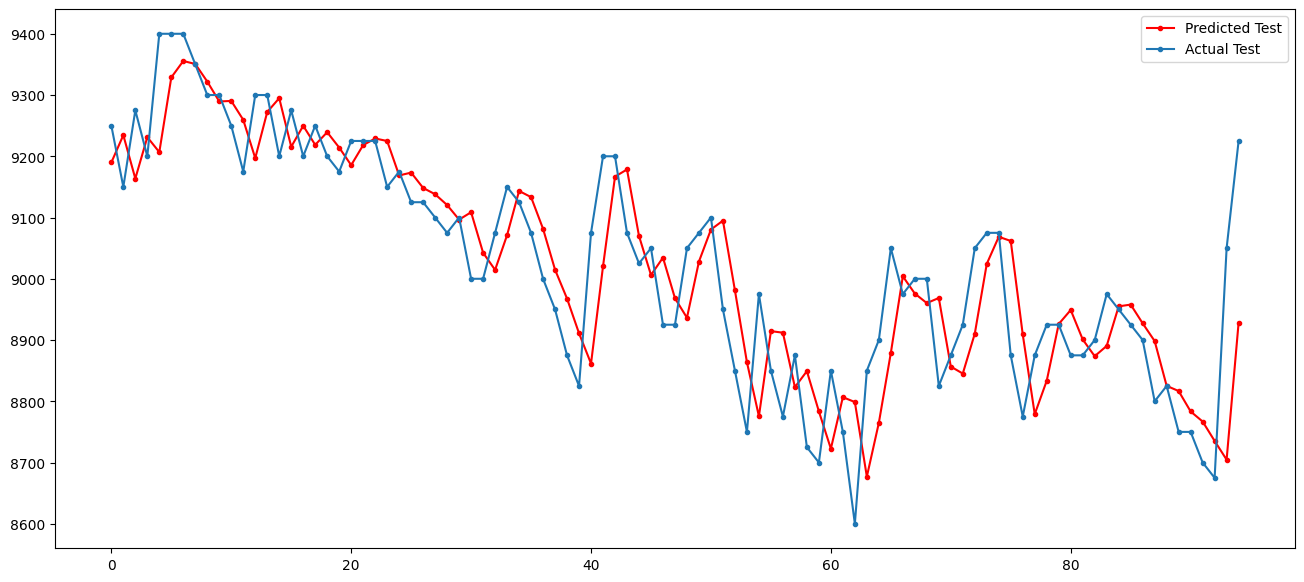

In [ ]:
plt.figure(figsize=(16,7))

plt.plot(predictions, 'r', marker='.', label='Predicted Test')
plt.plot(y_test, marker='.', label='Actual Test')

plt.legend()
plt.show()

In [ ]:

# Ambil 30 hari terakhir sebagai last_sequence
last_sequence = scaled_data_test[-30:]

# Inisialisasi tanggal terakhir
last_date = datetime.strptime(end_date, '%Y-%m-%d')
last_date = last_date - timedelta(days=1)
last_date = last_date.date()

# Lakukan prediksi untuk 22 hari ke depan
future_predictions = []
future_dates = []
future_days = 22

for _ in range(future_days):
    next_date = last_date + timedelta(days=1)

    # Lewati hari Sabtu dan Minggu (indeks 5 atau 6)
    while next_date.weekday() >= 5:
        next_date += timedelta(days=1)

    reshaped_sequence = last_sequence.reshape(1, last_sequence.shape[0], 1)

    # Prediksi harga untuk satu hari ke depan menggunakan model_saved
    prediction = model.predict(reshaped_sequence)[0][0]
    future_predictions.append(prediction)
    future_dates.append(next_date)

    # Perbarui urutan terakhir dengan menambahkan prediksi baru dan menghapus harga pertama dalam urutan
    last_sequence = np.append(last_sequence[1:], prediction)

    last_date = next_date

# Lakukan inversi scaling pada prediksi
future_predictions = np.array(future_predictions).reshape(-1, 1)
future_predictions = scaler.inverse_transform(future_predictions)

# Buat dataframe dari hasil prediksi
predicted_df = pd.DataFrame({'Tanggal': future_dates, 'Prediksi_Harga': future_predictions.flatten()})

# Tampilkan hasil prediksi
print(predicted_df)


1/1 [==============================] - 0s 25ms/step
       Tanggal  Prediksi_Harga
0   2023-12-18     9139.925781
1   2023-12-19     9108.786133
2   2023-12-20     9050.092773
3   2023-12-21     9012.494141
4   2023-12-22     8996.311523
5   2023-12-25     8994.047852
6   2023-12-26     8999.009766
7   2023-12-27     9006.212891
8   2023-12-28     9012.621094
9   2023-12-29     9017.019531
10  2024-01-01     9019.477539
11  2024-01-02     9020.659180
12  2024-01-03     9021.247070
13  2024-01-04     9021.740234
14  2024-01-05     9022.379883
15  2024-01-08     9023.233398
16  2024-01-09     9024.262695
17  2024-01-10     9025.383789
18  2024-01-11     9026.518555
19  2024-01-12     9027.599609
20  2024-01-15     9028.611328
21  2024-01-16     9029.554688


# Model




In [ ]:
import math
import numpy as np
from sklearn.preprocessing import MinMaxScaler


# Extract the 'Close' column from the data
close_prices = data['Close']

# Get the values from the 'Close' column as a NumPy array
values = close_prices.values

# Calculate the length of the training data by taking 80% of the total length of the 'values' array
training_data_len = math.ceil(len(values) * 0.8)

# Split the scaled data into training and test sets

train_data = close_prices[0 : training_data_len].values.reshape(-1,1)

#test_data = scaled_data[training_data_len - 30: , : ]
test_data = close_prices[training_data_len - 30 :].values.reshape(-1,1)

# Create a MinMaxScaler object and scale the values to the range [0, 1]
scaler = MinMaxScaler()
# scaled_data_train = scaler.fit_transform(train_data.reshape(-1, 1))
scaled_data_train = scaler.fit_transform(train_data)
scaled_data_test = scaler.fit_transform(test_data)


# Initialize empty lists for the training and test inputs and outputs
x_train, y_train = [], []
x_test = []

# Loop through the training data and create input/output pairs
for i in range(30, len(train_data)):
    x_train.append(scaled_data_train[i - 30: i, 0])
    y_train.append(scaled_data_train[i, 0])

# Convert the training inputs and outputs to NumPy arrays
x_train = np.array(x_train)
y_train = np.array(y_train)

# Reshape the training inputs to be 3D for use with an LSTM model
x_train = np.reshape(x_train, (x_train.shape[0], x_train.shape[1], 1))

# Loop through the test data and create input sequences
for i in range(30, len(test_data)):
    x_test.append(scaled_data_test[i - 30: i, 0])

# Convert the test inputs to a NumPy array and reshape to be 3D
x_test = np.array(x_test)
x_test = np.reshape(x_test, (x_test.shape[0], x_test.shape[1], 1))

# Get the test outputs as a NumPy array from the 'values' array
y_test = values[training_data_len:]

print('x_train shape:', x_train.shape)
print('y_train shape:', y_train.shape)
print('x_test shape:', x_test.shape)
print('y_test shape:', y_test.shape)

x_train shape: (352, 30, 1)
y_train shape: (352,)
x_test shape: (95, 30, 1)
y_test shape: (95,)


In [ ]:
len(test_data)

125

In [ ]:
# Set seed for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

model = keras.Sequential()
model.add(layers.LSTM(50, activation='tanh',return_sequences=True, input_shape=(x_train.shape[1], 1)))
model.add(layers.Dropout(0.2))  # Contoh penggunaan Dropout
model.add(layers.LSTM(50, return_sequences=True))
model.add(layers.Dropout(0.2))  # Contoh penggunaan Dropout
model.add(layers.LSTM(30, return_sequences=True))
model.add(layers.Dropout(0.2))  # Contoh penggunaan Dropout
model.add(layers.LSTM(60, return_sequences=False))
model.add(layers.Dropout(0.2))  # Contoh penggunaan Dropout
model.add(layers.Dense(1))
model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm_4 (LSTM)               (None, 30, 50)            10400     
                                                                 
 dropout_4 (Dropout)         (None, 30, 50)            0         
                                                                 
 lstm_5 (LSTM)               (None, 30, 50)            20200     
                                                                 
 dropout_5 (Dropout)         (None, 30, 50)            0         
                                                                 
 lstm_6 (LSTM)               (None, 30, 30)            9720      
                                                                 
 dropout_6 (Dropout)         (None, 30, 30)            0         
                                                                 
 lstm_7 (LSTM)               (None, 60)               

In [ ]:
np.random.seed(42)
tf.random.set_seed(42)

# Define and compile the model
model.compile(optimizer='adam', loss='mean_squared_error')

# Fit model dengan jumlah epochs yang ditentukan
model.fit(x_train, y_train, batch_size=16, epochs=200)

Epoch 1/200
22/22 [==============================] - 8s 42ms/step - loss: 0.0593
Epoch 2/200
22/22 [==============================] - 1s 42ms/step - loss: 0.0168
Epoch 3/200
22/22 [==============================] - 1s 42ms/step - loss: 0.0124
Epoch 4/200
22/22 [==============================] - 1s 42ms/step - loss: 0.0124
Epoch 5/200
22/22 [==============================] - 1s 41ms/step - loss: 0.0118
Epoch 6/200
22/22 [==============================] - 1s 42ms/step - loss: 0.0114
Epoch 7/200
22/22 [==============================] - 1s 42ms/step - loss: 0.0118
Epoch 8/200
22/22 [==============================] - 1s 63ms/step - loss: 0.0116
Epoch 9/200
22/22 [==============================] - 1s 64ms/step - loss: 0.0107
Epoch 10/200
22/22 [==============================] - 1s 61ms/step - loss: 0.0100
Epoch 11/200
22/22 [==============================] - 1s 43ms/step - loss: 0.0101
Epoch 12/200
22/22 [==============================] - 1s 42ms/step - loss: 0.0098
Epoch 13/200
22/22 [=====

In [ ]:
predictions = model.predict(x_train)

predictions = scaler.inverse_transform(predictions.reshape(-1,1))
y_train = scaler.inverse_transform(y_train.reshape(-1,1))

mse = mean_squared_error(predictions, y_train)
rmse = np.sqrt(mse)
print('Root mean squared error:', rmse)

11/11 [==============================] - 2s 16ms/step
Root mean squared error: 37.41542856522081


In [ ]:
predictions = model.predict(x_test)

predictions = scaler.inverse_transform(predictions.reshape(-1,1))

mse = mean_squared_error(predictions, y_test)
rmse = np.sqrt(mse)
print('Root mean squared error:', rmse)

3/3 [==============================] - 2s 17ms/step
Root mean squared error: 84.57805219435697


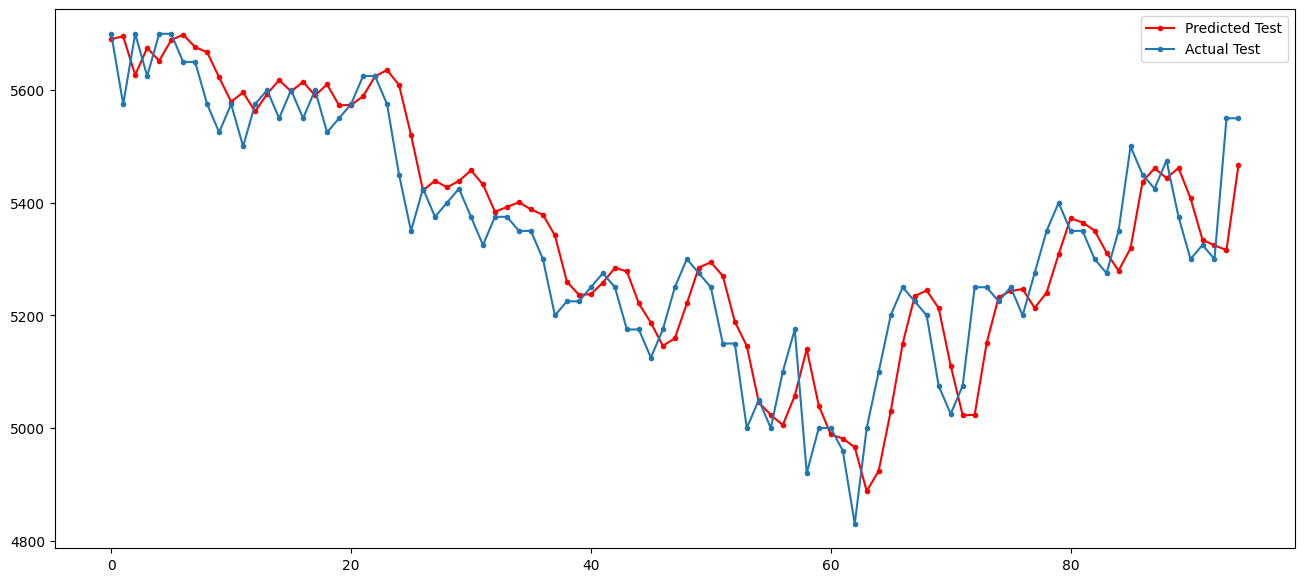

In [ ]:
plt.figure(figsize=(16,7))

plt.plot(predictions, 'r', marker='.', label='Predicted Test')
plt.plot(y_test, marker='.', label='Actual Test')

plt.legend()
plt.show()

In [ ]:

# Ambil 30 hari terakhir sebagai last_sequence
last_sequence = scaled_data_test[-30:]

# Inisialisasi tanggal terakhir
last_date = datetime.strptime(end_date, '%Y-%m-%d')
last_date = last_date - timedelta(days=1)
last_date = last_date.date()

# Lakukan prediksi untuk 30 hari ke depan
future_predictions = []
future_dates = []
future_days = 22

for _ in range(future_days):
    next_date = last_date + timedelta(days=1)

    # Lewati hari Sabtu dan Minggu (indeks 5 atau 6)
    while next_date.weekday() >= 5:
        next_date += timedelta(days=1)

    reshaped_sequence = last_sequence.reshape(1, last_sequence.shape[0], 1)

    # Prediksi harga untuk satu hari ke depan menggunakan model_saved
    prediction = model.predict(reshaped_sequence)[0][0]
    future_predictions.append(prediction)
    future_dates.append(next_date)

    # Perbarui urutan terakhir dengan menambahkan prediksi baru dan menghapus harga pertama dalam urutan
    last_sequence = np.append(last_sequence[1:], prediction)

    last_date = next_date

# Lakukan inversi scaling pada prediksi
future_predictions = np.array(future_predictions).reshape(-1, 1)
future_predictions = scaler.inverse_transform(future_predictions)

# Buat dataframe dari hasil prediksi
predicted_df = pd.DataFrame({'Tanggal': future_dates, 'Prediksi_Harga': future_predictions.flatten()})

# Tampilkan hasil prediksi
print(predicted_df)


1/1 [==============================] - 0s 26ms/step
       Tanggal  Prediksi_Harga
0   2023-12-18     5537.825195
1   2023-12-19     5550.720703
2   2023-12-20     5551.963867
3   2023-12-21     5550.416992
4   2023-12-22     5550.005859
5   2023-12-25     5551.640137
6   2023-12-26     5555.426270
7   2023-12-27     5561.050781
8   2023-12-28     5568.037598
9   2023-12-29     5575.886719
10  2024-01-01     5584.150391
11  2024-01-02     5592.477539
12  2024-01-03     5600.622559
13  2024-01-04     5608.437500
14  2024-01-05     5615.853027
15  2024-01-08     5622.855957
16  2024-01-09     5629.467285
17  2024-01-10     5635.721191
18  2024-01-11     5641.655762
19  2024-01-12     5647.301758
20  2024-01-15     5652.682129
21  2024-01-16     5657.812500


# Model




In [ ]:
import math
import numpy as np
from sklearn.preprocessing import MinMaxScaler


# Extract the 'Close' column from the data
close_prices = data['Close']

# Get the values from the 'Close' column as a NumPy array
values = close_prices.values

# Calculate the length of the training data by taking 80% of the total length of the 'values' array
training_data_len = math.ceil(len(values) * 0.8)

# Split the scaled data into training and test sets

train_data = close_prices[0 : training_data_len].values.reshape(-1,1)

#test_data = scaled_data[training_data_len - 30: , : ]
test_data = close_prices[training_data_len - 30 :].values.reshape(-1,1)

# Create a MinMaxScaler object and scale the values to the range [0, 1]
scaler = MinMaxScaler()
# scaled_data_train = scaler.fit_transform(train_data.reshape(-1, 1))
scaled_data_train = scaler.fit_transform(train_data)
scaled_data_test = scaler.fit_transform(test_data)


# Initialize empty lists for the training and test inputs and outputs
x_train, y_train = [], []
x_test = []

# Loop through the training data and create input/output pairs
for i in range(30, len(train_data)):
    x_train.append(scaled_data_train[i - 30: i, 0])
    y_train.append(scaled_data_train[i, 0])

# Convert the training inputs and outputs to NumPy arrays
x_train = np.array(x_train)
y_train = np.array(y_train)

# Reshape the training inputs to be 3D for use with an LSTM model
x_train = np.reshape(x_train, (x_train.shape[0], x_train.shape[1], 1))

# Loop through the test data and create input sequences
for i in range(30, len(test_data)):
    x_test.append(scaled_data_test[i - 30: i, 0])

# Convert the test inputs to a NumPy array and reshape to be 3D
x_test = np.array(x_test)
x_test = np.reshape(x_test, (x_test.shape[0], x_test.shape[1], 1))

# Get the test outputs as a NumPy array from the 'values' array
y_test = values[training_data_len:]

print('x_train shape:', x_train.shape)
print('y_train shape:', y_train.shape)
print('x_test shape:', x_test.shape)
print('y_test shape:', y_test.shape)

x_train shape: (352, 30, 1)
y_train shape: (352,)
x_test shape: (95, 30, 1)
y_test shape: (95,)


In [ ]:
len(test_data)

125

In [ ]:
# Set seed for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

model = keras.Sequential()
model.add(layers.LSTM(50, activation='tanh',return_sequences=True, input_shape=(x_train.shape[1], 1)))
model.add(layers.Dropout(0.2))  # Contoh penggunaan Dropout
model.add(layers.LSTM(50, return_sequences=True))
model.add(layers.Dropout(0.2))  # Contoh penggunaan Dropout
model.add(layers.LSTM(60, return_sequences=True))
model.add(layers.Dropout(0.2))  # Contoh penggunaan Dropout
model.add(layers.LSTM(60, return_sequences=False))
model.add(layers.Dropout(0.2))  # Contoh penggunaan Dropout
model.add(layers.Dense(1))
model.summary()

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm_8 (LSTM)               (None, 30, 50)            10400     
                                                                 
 dropout_8 (Dropout)         (None, 30, 50)            0         
                                                                 
 lstm_9 (LSTM)               (None, 30, 50)            20200     
                                                                 
 dropout_9 (Dropout)         (None, 30, 50)            0         
                                                                 
 lstm_10 (LSTM)              (None, 30, 60)            26640     
                                                                 
 dropout_10 (Dropout)        (None, 30, 60)            0         
                                                                 
 lstm_11 (LSTM)              (None, 60)               

In [ ]:
np.random.seed(42)
tf.random.set_seed(42)

# Define and compile the model
model.compile(optimizer='adam', loss='mean_squared_error')

# Fit model dengan jumlah epochs yang ditentukan
model.fit(x_train, y_train, batch_size=16, epochs=200)

Epoch 1/200
22/22 [==============================] - 9s 47ms/step - loss: 0.0541
Epoch 2/200
22/22 [==============================] - 1s 47ms/step - loss: 0.0162
Epoch 3/200
22/22 [==============================] - 1s 46ms/step - loss: 0.0132
Epoch 4/200
22/22 [==============================] - 1s 47ms/step - loss: 0.0108
Epoch 5/200
22/22 [==============================] - 1s 47ms/step - loss: 0.0128
Epoch 6/200
22/22 [==============================] - 1s 45ms/step - loss: 0.0116
Epoch 7/200
22/22 [==============================] - 1s 61ms/step - loss: 0.0118
Epoch 8/200
22/22 [==============================] - 2s 71ms/step - loss: 0.0113
Epoch 9/200
22/22 [==============================] - 1s 64ms/step - loss: 0.0119
Epoch 10/200
22/22 [==============================] - 1s 45ms/step - loss: 0.0105
Epoch 11/200
22/22 [==============================] - 1s 45ms/step - loss: 0.0096
Epoch 12/200
22/22 [==============================] - 1s 45ms/step - loss: 0.0103
Epoch 13/200
22/22 [=====

In [ ]:
predictions = model.predict(x_train)

predictions = scaler.inverse_transform(predictions.reshape(-1,1))
y_train = scaler.inverse_transform(y_train.reshape(-1,1))

mse = mean_squared_error(predictions, y_train)
rmse = np.sqrt(mse)
print('Root mean squared error:', rmse)

11/11 [==============================] - 2s 18ms/step
Root mean squared error: 37.13254727876935


In [ ]:
predictions = model.predict(x_test)

predictions = scaler.inverse_transform(predictions.reshape(-1,1))

mse = mean_squared_error(predictions, y_test)
rmse = np.sqrt(mse)
print('Root mean squared error:', rmse)

3/3 [==============================] - 2s 17ms/step
Root mean squared error: 83.98254193983524


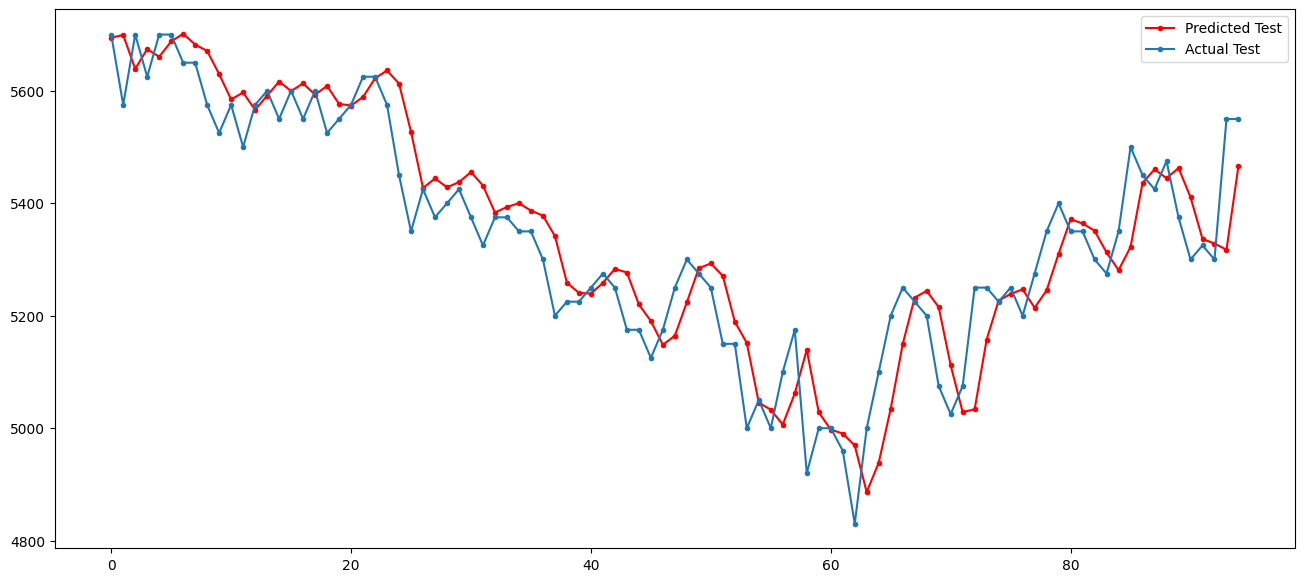

In [ ]:
plt.figure(figsize=(16,7))

plt.plot(predictions, 'r', marker='.', label='Predicted Test')
plt.plot(y_test, marker='.', label='Actual Test')

plt.legend()
plt.show()

In [ ]:

# Ambil 30 hari terakhir sebagai last_sequence
last_sequence = scaled_data_test[-30:]

# Inisialisasi tanggal terakhir
last_date = datetime.strptime(end_date, '%Y-%m-%d')
last_date = last_date - timedelta(days=1)
last_date = last_date.date()

# Lakukan prediksi untuk 30 hari ke depan
future_predictions = []
future_dates = []
future_days = 22

for _ in range(future_days):
    next_date = last_date + timedelta(days=1)

    # Lewati hari Sabtu dan Minggu (indeks 5 atau 6)
    while next_date.weekday() >= 5:
        next_date += timedelta(days=1)

    reshaped_sequence = last_sequence.reshape(1, last_sequence.shape[0], 1)

    # Prediksi harga untuk satu hari ke depan menggunakan model_saved
    prediction = model.predict(reshaped_sequence)[0][0]
    future_predictions.append(prediction)
    future_dates.append(next_date)

    # Perbarui urutan terakhir dengan menambahkan prediksi baru dan menghapus harga pertama dalam urutan
    last_sequence = np.append(last_sequence[1:], prediction)

    last_date = next_date

# Lakukan inversi scaling pada prediksi
future_predictions = np.array(future_predictions).reshape(-1, 1)
future_predictions = scaler.inverse_transform(future_predictions)

# Buat dataframe dari hasil prediksi
predicted_df = pd.DataFrame({'Tanggal': future_dates, 'Prediksi_Harga': future_predictions.flatten()})

# Tampilkan hasil prediksi
print(predicted_df)


1/1 [==============================] - 0s 26ms/step
       Tanggal  Prediksi_Harga
0   2023-12-18     5535.348633
1   2023-12-19     5549.599609
2   2023-12-20     5551.658203
3   2023-12-21     5551.491211
4   2023-12-22     5552.125977
5   2023-12-25     5554.606934
6   2023-12-26     5559.126465
7   2023-12-27     5565.431152
8   2023-12-28     5573.047852
9   2023-12-29     5581.474121
10  2024-01-01     5590.251953
11  2024-01-02     5599.018066
12  2024-01-03     5607.540527
13  2024-01-04     5615.679199
14  2024-01-05     5623.386719
15  2024-01-08     5630.674316
16  2024-01-09     5637.590820
17  2024-01-10     5644.182617
18  2024-01-11     5650.497559
19  2024-01-12     5656.565430
20  2024-01-15     5662.393555
21  2024-01-16     5667.979004


# Model




In [ ]:
import math
import numpy as np
from sklearn.preprocessing import MinMaxScaler


# Extract the 'Close' column from the data
close_prices = data['Close']

# Get the values from the 'Close' column as a NumPy array
values = close_prices.values

# Calculate the length of the training data by taking 80% of the total length of the 'values' array
training_data_len = math.ceil(len(values) * 0.8)

# Split the scaled data into training and test sets

train_data = close_prices[0 : training_data_len].values.reshape(-1,1)

#test_data = scaled_data[training_data_len - 30: , : ]
test_data = close_prices[training_data_len - 30 :].values.reshape(-1,1)

# Create a MinMaxScaler object and scale the values to the range [0, 1]
scaler = MinMaxScaler()
# scaled_data_train = scaler.fit_transform(train_data.reshape(-1, 1))
scaled_data_train = scaler.fit_transform(train_data)
scaled_data_test = scaler.fit_transform(test_data)


# Initialize empty lists for the training and test inputs and outputs
x_train, y_train = [], []
x_test = []

# Loop through the training data and create input/output pairs
for i in range(30, len(train_data)):
    x_train.append(scaled_data_train[i - 30: i, 0])
    y_train.append(scaled_data_train[i, 0])

# Convert the training inputs and outputs to NumPy arrays
x_train = np.array(x_train)
y_train = np.array(y_train)

# Reshape the training inputs to be 3D for use with an LSTM model
x_train = np.reshape(x_train, (x_train.shape[0], x_train.shape[1], 1))

# Loop through the test data and create input sequences
for i in range(30, len(test_data)):
    x_test.append(scaled_data_test[i - 30: i, 0])

# Convert the test inputs to a NumPy array and reshape to be 3D
x_test = np.array(x_test)
x_test = np.reshape(x_test, (x_test.shape[0], x_test.shape[1], 1))

# Get the test outputs as a NumPy array from the 'values' array
y_test = values[training_data_len:]

print('x_train shape:', x_train.shape)
print('y_train shape:', y_train.shape)
print('x_test shape:', x_test.shape)
print('y_test shape:', y_test.shape)

x_train shape: (352, 30, 1)
y_train shape: (352,)
x_test shape: (95, 30, 1)
y_test shape: (95,)


In [ ]:
len(test_data)

125

In [ ]:
# Set seed for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

model = keras.Sequential()
model.add(layers.LSTM(50, activation='tanh',return_sequences=True, input_shape=(x_train.shape[1], 1)))
model.add(layers.Dropout(0.2))  # Contoh penggunaan Dropout
model.add(layers.LSTM(50, return_sequences=True))
model.add(layers.Dropout(0.2))  # Contoh penggunaan Dropout
model.add(layers.LSTM(60, return_sequences=True))
model.add(layers.Dropout(0.2))  # Contoh penggunaan Dropout
model.add(layers.LSTM(30, return_sequences=False))
model.add(layers.Dropout(0.2))  # Contoh penggunaan Dropout
model.add(layers.Dense(1))
model.summary()

Model: "sequential_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm_12 (LSTM)              (None, 30, 50)            10400     
                                                                 
 dropout_12 (Dropout)        (None, 30, 50)            0         
                                                                 
 lstm_13 (LSTM)              (None, 30, 50)            20200     
                                                                 
 dropout_13 (Dropout)        (None, 30, 50)            0         
                                                                 
 lstm_14 (LSTM)              (None, 30, 60)            26640     
                                                                 
 dropout_14 (Dropout)        (None, 30, 60)            0         
                                                                 
 lstm_15 (LSTM)              (None, 30)               

In [ ]:
np.random.seed(42)
tf.random.set_seed(42)

# Define and compile the model
model.compile(optimizer='adam', loss='mean_squared_error')

# Fit model dengan jumlah epochs yang ditentukan
model.fit(x_train, y_train, batch_size=16, epochs=200)

Epoch 1/200
22/22 [==============================] - 8s 43ms/step - loss: 0.0618
Epoch 2/200
22/22 [==============================] - 1s 43ms/step - loss: 0.0192
Epoch 3/200
22/22 [==============================] - 1s 44ms/step - loss: 0.0154
Epoch 4/200
22/22 [==============================] - 1s 43ms/step - loss: 0.0146
Epoch 5/200
22/22 [==============================] - 1s 43ms/step - loss: 0.0136
Epoch 6/200
22/22 [==============================] - 1s 43ms/step - loss: 0.0137
Epoch 7/200
22/22 [==============================] - 1s 43ms/step - loss: 0.0140
Epoch 8/200
22/22 [==============================] - 1s 55ms/step - loss: 0.0116
Epoch 9/200
22/22 [==============================] - 1s 66ms/step - loss: 0.0146
Epoch 10/200
22/22 [==============================] - 1s 66ms/step - loss: 0.0120
Epoch 11/200
22/22 [==============================] - 1s 45ms/step - loss: 0.0113
Epoch 12/200
22/22 [==============================] - 1s 44ms/step - loss: 0.0123
Epoch 13/200
22/22 [=====

In [ ]:
predictions = model.predict(x_train)

predictions = scaler.inverse_transform(predictions.reshape(-1,1))
y_train = scaler.inverse_transform(y_train.reshape(-1,1))

mse = mean_squared_error(predictions, y_train)
rmse = np.sqrt(mse)
print('Root mean squared error:', rmse)

11/11 [==============================] - 2s 19ms/step
Root mean squared error: 38.2287957538939


In [ ]:
predictions = model.predict(x_test)

predictions = scaler.inverse_transform(predictions.reshape(-1,1))

mse = mean_squared_error(predictions, y_test)
rmse = np.sqrt(mse)
print('Root mean squared error:', rmse)

3/3 [==============================] - 2s 18ms/step
Root mean squared error: 79.9875634421357


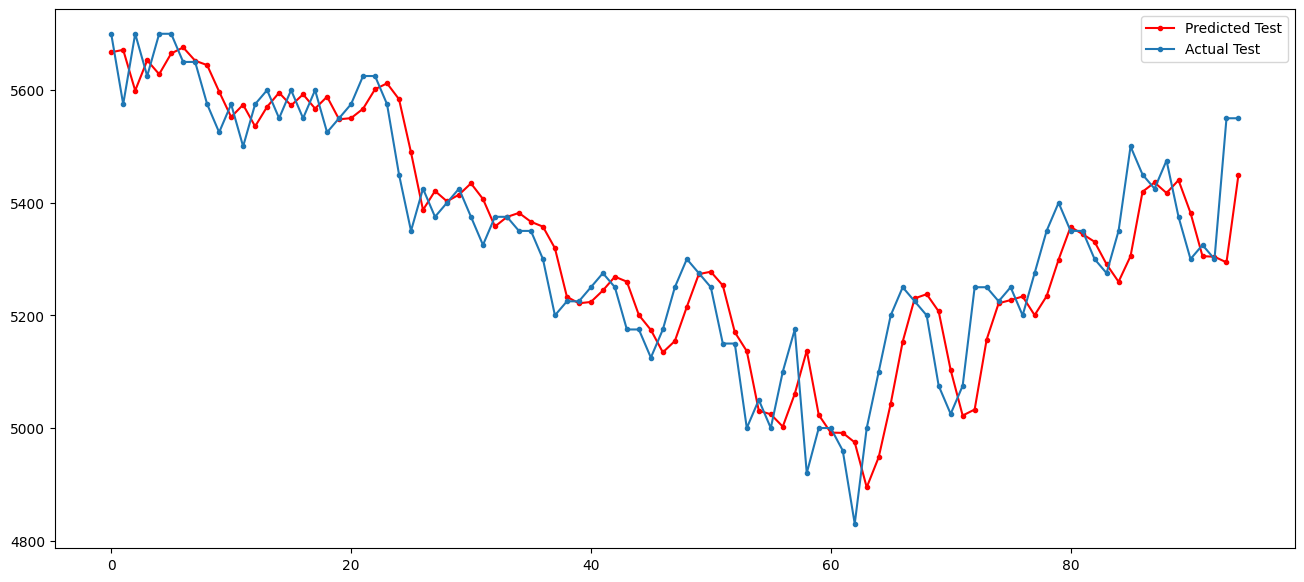

In [ ]:
plt.figure(figsize=(16,7))

plt.plot(predictions, 'r', marker='.', label='Predicted Test')
plt.plot(y_test, marker='.', label='Actual Test')

plt.legend()
plt.show()

In [ ]:

# Ambil 30 hari terakhir sebagai last_sequence
last_sequence = scaled_data_test[-30:]

# Inisialisasi tanggal terakhir
last_date = datetime.strptime(end_date, '%Y-%m-%d')
last_date = last_date - timedelta(days=1)
last_date = last_date.date()

# Lakukan prediksi untuk 30 hari ke depan
future_predictions = []
future_dates = []
future_days = 22

for _ in range(future_days):
    next_date = last_date + timedelta(days=1)

    # Lewati hari Sabtu dan Minggu (indeks 5 atau 6)
    while next_date.weekday() >= 5:
        next_date += timedelta(days=1)

    reshaped_sequence = last_sequence.reshape(1, last_sequence.shape[0], 1)

    # Prediksi harga untuk satu hari ke depan menggunakan model_saved
    prediction = model.predict(reshaped_sequence)[0][0]
    future_predictions.append(prediction)
    future_dates.append(next_date)

    # Perbarui urutan terakhir dengan menambahkan prediksi baru dan menghapus harga pertama dalam urutan
    last_sequence = np.append(last_sequence[1:], prediction)

    last_date = next_date

# Lakukan inversi scaling pada prediksi
future_predictions = np.array(future_predictions).reshape(-1, 1)
future_predictions = scaler.inverse_transform(future_predictions)

# Buat dataframe dari hasil prediksi
predicted_df = pd.DataFrame({'Tanggal': future_dates, 'Prediksi_Harga': future_predictions.flatten()})

# Tampilkan hasil prediksi
print(predicted_df)


1/1 [==============================] - 0s 28ms/step
       Tanggal  Prediksi_Harga
0   2023-12-18     5511.225586
1   2023-12-19     5507.056641
2   2023-12-20     5493.937500
3   2023-12-21     5479.546875
4   2023-12-22     5466.429199
5   2023-12-25     5455.550293
6   2023-12-26     5447.234375
7   2023-12-27     5441.364746
8   2023-12-28     5437.559082
9   2023-12-29     5435.324707
10  2024-01-01     5434.153320
11  2024-01-02     5433.583496
12  2024-01-03     5433.245117
13  2024-01-04     5432.861816
14  2024-01-05     5432.254883
15  2024-01-08     5431.333496
16  2024-01-09     5430.077637
17  2024-01-10     5428.504883
18  2024-01-11     5426.664551
19  2024-01-12     5424.612793
20  2024-01-15     5422.399902
21  2024-01-16     5420.067871


# Model




In [ ]:
import math
import numpy as np
from sklearn.preprocessing import MinMaxScaler


# Extract the 'Close' column from the data
close_prices = data['Close']

# Get the values from the 'Close' column as a NumPy array
values = close_prices.values

# Calculate the length of the training data by taking 80% of the total length of the 'values' array
training_data_len = math.ceil(len(values) * 0.8)

# Split the scaled data into training and test sets

train_data = close_prices[0 : training_data_len].values.reshape(-1,1)

#test_data = scaled_data[training_data_len - 30: , : ]
test_data = close_prices[training_data_len - 30 :].values.reshape(-1,1)

# Create a MinMaxScaler object and scale the values to the range [0, 1]
scaler = MinMaxScaler()
# scaled_data_train = scaler.fit_transform(train_data.reshape(-1, 1))
scaled_data_train = scaler.fit_transform(train_data)
scaled_data_test = scaler.fit_transform(test_data)


# Initialize empty lists for the training and test inputs and outputs
x_train, y_train = [], []
x_test = []

# Loop through the training data and create input/output pairs
for i in range(30, len(train_data)):
    x_train.append(scaled_data_train[i - 30: i, 0])
    y_train.append(scaled_data_train[i, 0])

# Convert the training inputs and outputs to NumPy arrays
x_train = np.array(x_train)
y_train = np.array(y_train)

# Reshape the training inputs to be 3D for use with an LSTM model
x_train = np.reshape(x_train, (x_train.shape[0], x_train.shape[1], 1))

# Loop through the test data and create input sequences
for i in range(30, len(test_data)):
    x_test.append(scaled_data_test[i - 30: i, 0])

# Convert the test inputs to a NumPy array and reshape to be 3D
x_test = np.array(x_test)
x_test = np.reshape(x_test, (x_test.shape[0], x_test.shape[1], 1))

# Get the test outputs as a NumPy array from the 'values' array
y_test = values[training_data_len:]

print('x_train shape:', x_train.shape)
print('y_train shape:', y_train.shape)
print('x_test shape:', x_test.shape)
print('y_test shape:', y_test.shape)

x_train shape: (352, 30, 1)
y_train shape: (352,)
x_test shape: (95, 30, 1)
y_test shape: (95,)


In [ ]:
len(test_data)

125

In [ ]:
# Set seed for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

model = keras.Sequential()
model.add(layers.LSTM(50, activation='tanh',return_sequences=True, input_shape=(x_train.shape[1], 1)))
model.add(layers.Dropout(0.2))  # Contoh penggunaan Dropout
model.add(layers.LSTM(50, return_sequences=True))
model.add(layers.Dropout(0.2))  # Contoh penggunaan Dropout
model.add(layers.LSTM(50, return_sequences=True))
model.add(layers.Dropout(0.2))  # Contoh penggunaan Dropout
model.add(layers.LSTM(50, return_sequences=False))
model.add(layers.Dropout(0.2))  # Contoh penggunaan Dropout
model.add(layers.Dense(1))
model.summary()

Model: "sequential_4"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm_16 (LSTM)              (None, 30, 50)            10400     
                                                                 
 dropout_16 (Dropout)        (None, 30, 50)            0         
                                                                 
 lstm_17 (LSTM)              (None, 30, 50)            20200     
                                                                 
 dropout_17 (Dropout)        (None, 30, 50)            0         
                                                                 
 lstm_18 (LSTM)              (None, 30, 50)            20200     
                                                                 
 dropout_18 (Dropout)        (None, 30, 50)            0         
                                                                 
 lstm_19 (LSTM)              (None, 50)               

In [ ]:
np.random.seed(42)
tf.random.set_seed(42)

# Define and compile the model
model.compile(optimizer='adam', loss='mean_squared_error')

# Fit model dengan jumlah epochs yang ditentukan
model.fit(x_train, y_train, batch_size=16, epochs=200)

Epoch 1/200
22/22 [==============================] - 8s 47ms/step - loss: 0.0535
Epoch 2/200
22/22 [==============================] - 1s 44ms/step - loss: 0.0165
Epoch 3/200
22/22 [==============================] - 1s 49ms/step - loss: 0.0136
Epoch 4/200
22/22 [==============================] - 1s 48ms/step - loss: 0.0136
Epoch 5/200
22/22 [==============================] - 1s 45ms/step - loss: 0.0135
Epoch 6/200
22/22 [==============================] - 1s 53ms/step - loss: 0.0131
Epoch 7/200
22/22 [==============================] - 1s 66ms/step - loss: 0.0115
Epoch 8/200
22/22 [==============================] - 1s 66ms/step - loss: 0.0107
Epoch 9/200
22/22 [==============================] - 1s 48ms/step - loss: 0.0134
Epoch 10/200
22/22 [==============================] - 1s 44ms/step - loss: 0.0141
Epoch 11/200
22/22 [==============================] - 1s 44ms/step - loss: 0.0117
Epoch 12/200
22/22 [==============================] - 1s 46ms/step - loss: 0.0112
Epoch 13/200
22/22 [=====

In [ ]:
predictions = model.predict(x_train)

predictions = scaler.inverse_transform(predictions.reshape(-1,1))
y_train = scaler.inverse_transform(y_train.reshape(-1,1))

mse = mean_squared_error(predictions, y_train)
rmse = np.sqrt(mse)
print('Root mean squared error:', rmse)

11/11 [==============================] - 2s 17ms/step
Root mean squared error: 37.868262586529454


In [ ]:
predictions = model.predict(x_test)

predictions = scaler.inverse_transform(predictions.reshape(-1,1))

mse = mean_squared_error(predictions, y_test)
rmse = np.sqrt(mse)
print('Root mean squared error:', rmse)

3/3 [==============================] - 2s 20ms/step
Root mean squared error: 79.98560586794255


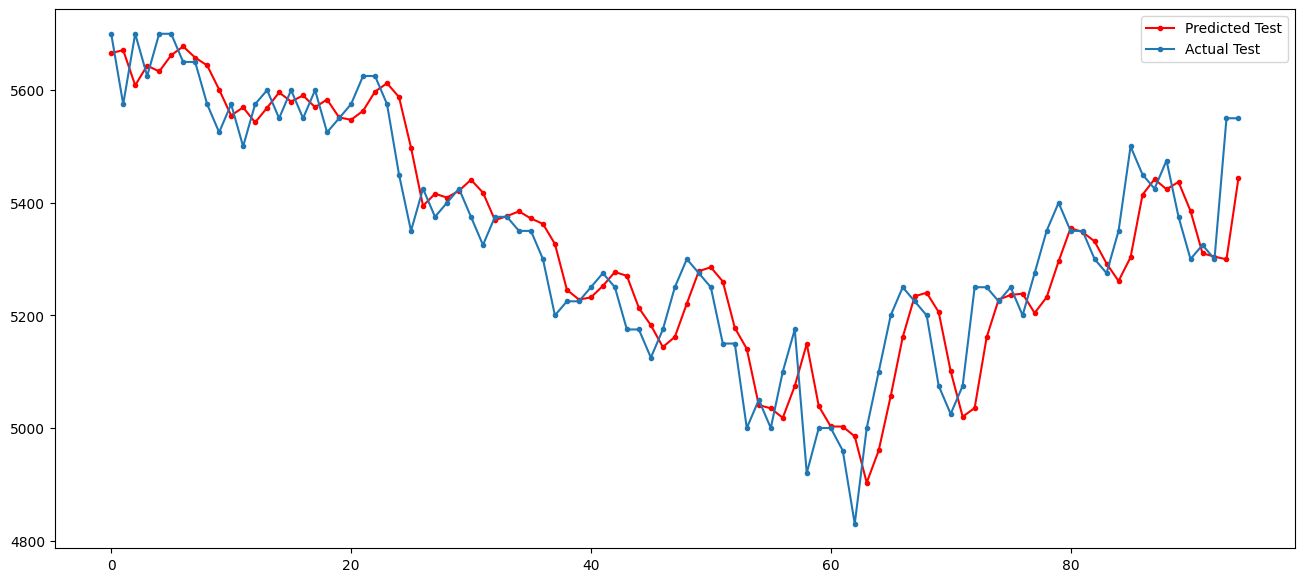

In [ ]:
plt.figure(figsize=(16,7))

plt.plot(predictions, 'r', marker='.', label='Predicted Test')
plt.plot(y_test, marker='.', label='Actual Test')

plt.legend()
plt.show()

In [ ]:

# Ambil 30 hari terakhir sebagai last_sequence
last_sequence = scaled_data_test[-30:]

# Inisialisasi tanggal terakhir
last_date = datetime.strptime(end_date, '%Y-%m-%d')
last_date = last_date - timedelta(days=1)
last_date = last_date.date()

# Lakukan prediksi untuk 30 hari ke depan
future_predictions = []
future_dates = []
future_days = 22

for _ in range(future_days):
    next_date = last_date + timedelta(days=1)

    # Lewati hari Sabtu dan Minggu (indeks 5 atau 6)
    while next_date.weekday() >= 5:
        next_date += timedelta(days=1)

    reshaped_sequence = last_sequence.reshape(1, last_sequence.shape[0], 1)

    # Prediksi harga untuk satu hari ke depan menggunakan model_saved
    prediction = model.predict(reshaped_sequence)[0][0]
    future_predictions.append(prediction)
    future_dates.append(next_date)

    # Perbarui urutan terakhir dengan menambahkan prediksi baru dan menghapus harga pertama dalam urutan
    last_sequence = np.append(last_sequence[1:], prediction)

    last_date = next_date

# Lakukan inversi scaling pada prediksi
future_predictions = np.array(future_predictions).reshape(-1, 1)
future_predictions = scaler.inverse_transform(future_predictions)

# Buat dataframe dari hasil prediksi
predicted_df = pd.DataFrame({'Tanggal': future_dates, 'Prediksi_Harga': future_predictions.flatten()})

# Tampilkan hasil prediksi
print(predicted_df)


1/1 [==============================] - 0s 44ms/step
       Tanggal  Prediksi_Harga
0   2023-12-18     5515.664062
1   2023-12-19     5519.753418
2   2023-12-20     5504.468750
3   2023-12-21     5485.445312
4   2023-12-22     5468.249512
5   2023-12-25     5455.197754
6   2023-12-26     5446.824707
7   2023-12-27     5442.578613
8   2023-12-28     5441.400879
9   2023-12-29     5442.138184
10  2024-01-01     5443.768555
11  2024-01-02     5445.512207
12  2024-01-03     5446.868652
13  2024-01-04     5447.580566
14  2024-01-05     5447.591797
15  2024-01-08     5446.980469
16  2024-01-09     5445.896973
17  2024-01-10     5444.508789
18  2024-01-11     5442.968750
19  2024-01-12     5441.394043
20  2024-01-15     5439.856934
21  2024-01-16     5438.392578


# Model




In [ ]:
import math
import numpy as np
from sklearn.preprocessing import MinMaxScaler


# Extract the 'Close' column from the data
close_prices = data['Close']

# Get the values from the 'Close' column as a NumPy array
values = close_prices.values

# Calculate the length of the training data by taking 80% of the total length of the 'values' array
training_data_len = math.ceil(len(values) * 0.8)

# Split the scaled data into training and test sets

train_data = close_prices[0 : training_data_len].values.reshape(-1,1)

#test_data = scaled_data[training_data_len - 30: , : ]
test_data = close_prices[training_data_len - 30 :].values.reshape(-1,1)

# Create a MinMaxScaler object and scale the values to the range [0, 1]
scaler = MinMaxScaler()
# scaled_data_train = scaler.fit_transform(train_data.reshape(-1, 1))
scaled_data_train = scaler.fit_transform(train_data)
scaled_data_test = scaler.fit_transform(test_data)


# Initialize empty lists for the training and test inputs and outputs
x_train, y_train = [], []
x_test = []

# Loop through the training data and create input/output pairs
for i in range(30, len(train_data)):
    x_train.append(scaled_data_train[i - 30: i, 0])
    y_train.append(scaled_data_train[i, 0])

# Convert the training inputs and outputs to NumPy arrays
x_train = np.array(x_train)
y_train = np.array(y_train)

# Reshape the training inputs to be 3D for use with an LSTM model
x_train = np.reshape(x_train, (x_train.shape[0], x_train.shape[1], 1))

# Loop through the test data and create input sequences
for i in range(30, len(test_data)):
    x_test.append(scaled_data_test[i - 30: i, 0])

# Convert the test inputs to a NumPy array and reshape to be 3D
x_test = np.array(x_test)
x_test = np.reshape(x_test, (x_test.shape[0], x_test.shape[1], 1))

# Get the test outputs as a NumPy array from the 'values' array
y_test = values[training_data_len:]

print('x_train shape:', x_train.shape)
print('y_train shape:', y_train.shape)
print('x_test shape:', x_test.shape)
print('y_test shape:', y_test.shape)

x_train shape: (352, 30, 1)
y_train shape: (352,)
x_test shape: (95, 30, 1)
y_test shape: (95,)


In [ ]:
len(test_data)

125

In [ ]:
# Set seed for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

model = keras.Sequential()
model.add(layers.LSTM(50, activation='tanh',return_sequences=True, input_shape=(x_train.shape[1], 1)))
model.add(layers.Dropout(0.2))  # Contoh penggunaan Dropout
model.add(layers.LSTM(50, return_sequences=True))
model.add(layers.Dropout(0.2))  # Contoh penggunaan Dropout
model.add(layers.LSTM(50, return_sequences=True))
model.add(layers.Dropout(0.2))  # Contoh penggunaan Dropout
model.add(layers.LSTM(30, return_sequences=False))
model.add(layers.Dropout(0.2))  # Contoh penggunaan Dropout
model.add(layers.Dense(1))
model.summary()

Model: "sequential_7"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm_28 (LSTM)              (None, 30, 50)            10400     
                                                                 
 dropout_28 (Dropout)        (None, 30, 50)            0         
                                                                 
 lstm_29 (LSTM)              (None, 30, 50)            20200     
                                                                 
 dropout_29 (Dropout)        (None, 30, 50)            0         
                                                                 
 lstm_30 (LSTM)              (None, 30, 50)            20200     
                                                                 
 dropout_30 (Dropout)        (None, 30, 50)            0         
                                                                 
 lstm_31 (LSTM)              (None, 30)               

In [ ]:
np.random.seed(42)
tf.random.set_seed(42)

# Define and compile the model
model.compile(optimizer='adam', loss='mean_squared_error')

# Fit model dengan jumlah epochs yang ditentukan
model.fit(x_train, y_train, batch_size=16, epochs=200)

Epoch 1/200
22/22 [==============================] - 10s 54ms/step - loss: 0.0642
Epoch 2/200
22/22 [==============================] - 1s 55ms/step - loss: 0.0190
Epoch 3/200
22/22 [==============================] - 1s 55ms/step - loss: 0.0159
Epoch 4/200
22/22 [==============================] - 1s 55ms/step - loss: 0.0142
Epoch 5/200
22/22 [==============================] - 1s 54ms/step - loss: 0.0139
Epoch 6/200
22/22 [==============================] - 1s 52ms/step - loss: 0.0132
Epoch 7/200
22/22 [==============================] - 1s 56ms/step - loss: 0.0129
Epoch 8/200
22/22 [==============================] - 1s 60ms/step - loss: 0.0121
Epoch 9/200
22/22 [==============================] - 2s 79ms/step - loss: 0.0138
Epoch 10/200
22/22 [==============================] - 2s 75ms/step - loss: 0.0116
Epoch 11/200
22/22 [==============================] - 1s 60ms/step - loss: 0.0112
Epoch 12/200
22/22 [==============================] - 1s 58ms/step - loss: 0.0122
Epoch 13/200
22/22 [====

In [ ]:
predictions = model.predict(x_train)

predictions = scaler.inverse_transform(predictions.reshape(-1,1))
y_train = scaler.inverse_transform(y_train.reshape(-1,1))

mse = mean_squared_error(predictions, y_train)
rmse = np.sqrt(mse)
print('Root mean squared error:', rmse)

11/11 [==============================] - 2s 23ms/step
Root mean squared error: 36.7196534690877


In [ ]:
predictions = model.predict(x_test)

predictions = scaler.inverse_transform(predictions.reshape(-1,1))

mse = mean_squared_error(predictions, y_test)
rmse = np.sqrt(mse)
print('Root mean squared error:', rmse)

3/3 [==============================] - 2s 20ms/step
Root mean squared error: 81.67133157619277


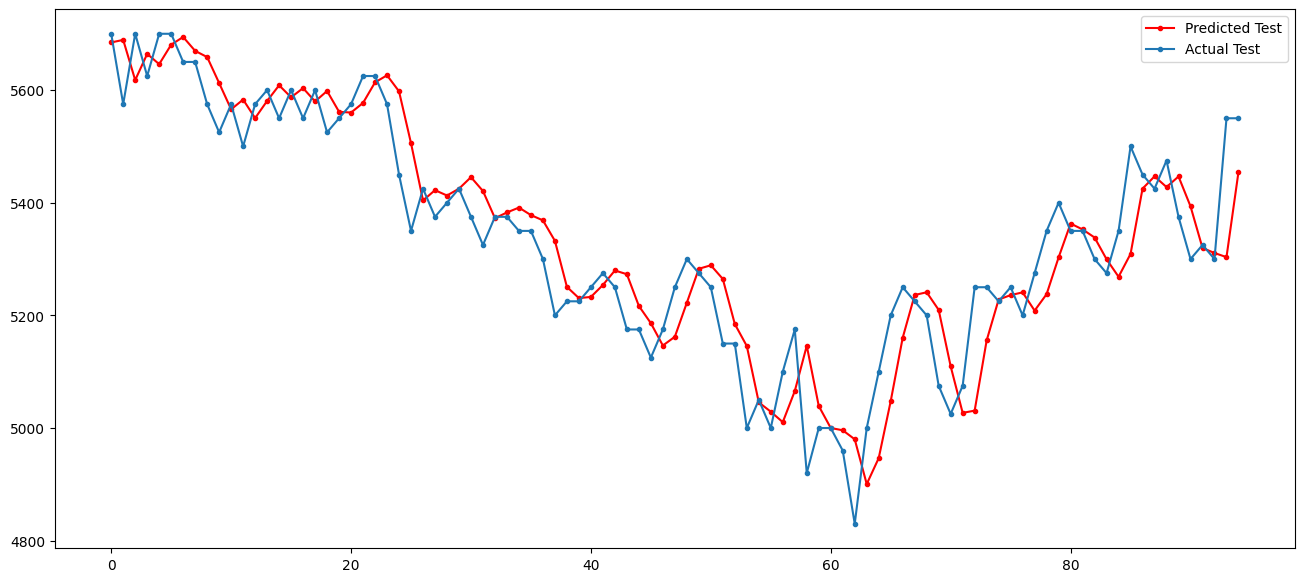

In [ ]:
plt.figure(figsize=(16,7))

plt.plot(predictions, 'r', marker='.', label='Predicted Test')
plt.plot(y_test, marker='.', label='Actual Test')

plt.legend()
plt.show()

In [ ]:

# Ambil 30 hari terakhir sebagai last_sequence
last_sequence = scaled_data_test[-30:]

# Inisialisasi tanggal terakhir
last_date = datetime.strptime(end_date, '%Y-%m-%d')
last_date = last_date - timedelta(days=1)
last_date = last_date.date()

# Lakukan prediksi untuk 30 hari ke depan
future_predictions = []
future_dates = []
future_days = 22

for _ in range(future_days):
    next_date = last_date + timedelta(days=1)

    # Lewati hari Sabtu dan Minggu (indeks 5 atau 6)
    while next_date.weekday() >= 5:
        next_date += timedelta(days=1)

    reshaped_sequence = last_sequence.reshape(1, last_sequence.shape[0], 1)

    # Prediksi harga untuk satu hari ke depan menggunakan model_saved
    prediction = model.predict(reshaped_sequence)[0][0]
    future_predictions.append(prediction)
    future_dates.append(next_date)

    # Perbarui urutan terakhir dengan menambahkan prediksi baru dan menghapus harga pertama dalam urutan
    last_sequence = np.append(last_sequence[1:], prediction)

    last_date = next_date

# Lakukan inversi scaling pada prediksi
future_predictions = np.array(future_predictions).reshape(-1, 1)
future_predictions = scaler.inverse_transform(future_predictions)

# Buat dataframe dari hasil prediksi
predicted_df = pd.DataFrame({'Tanggal': future_dates, 'Prediksi_Harga': future_predictions.flatten()})

# Tampilkan hasil prediksi
print(predicted_df)


1/1 [==============================] - 0s 47ms/step
       Tanggal  Prediksi_Harga
0   2023-12-18     5524.641602
1   2023-12-19     5527.385254
2   2023-12-20     5518.905273
3   2023-12-21     5508.861816
4   2023-12-22     5500.528809
5   2023-12-25     5494.873535
6   2023-12-26     5492.106934
7   2023-12-27     5491.969727
8   2023-12-28     5493.920410
9   2023-12-29     5497.348633
10  2024-01-01     5501.655273
11  2024-01-02     5506.336914
12  2024-01-03     5511.038574
13  2024-01-04     5515.521484
14  2024-01-05     5519.676758
15  2024-01-08     5523.492676
16  2024-01-09     5527.030762
17  2024-01-10     5530.365234
18  2024-01-11     5533.588379
19  2024-01-12     5536.770020
20  2024-01-15     5539.948730
21  2024-01-16     5543.139648


# Model




In [ ]:
import math
import numpy as np
from sklearn.preprocessing import MinMaxScaler


# Extract the 'Close' column from the data
close_prices = data['Close']

# Get the values from the 'Close' column as a NumPy array
values = close_prices.values

# Calculate the length of the training data by taking 80% of the total length of the 'values' array
training_data_len = math.ceil(len(values) * 0.8)

# Split the scaled data into training and test sets

train_data = close_prices[0 : training_data_len].values.reshape(-1,1)

#test_data = scaled_data[training_data_len - 30: , : ]
test_data = close_prices[training_data_len - 30 :].values.reshape(-1,1)

# Create a MinMaxScaler object and scale the values to the range [0, 1]
scaler = MinMaxScaler()
# scaled_data_train = scaler.fit_transform(train_data.reshape(-1, 1))
scaled_data_train = scaler.fit_transform(train_data)
scaled_data_test = scaler.fit_transform(test_data)


# Initialize empty lists for the training and test inputs and outputs
x_train, y_train = [], []
x_test = []

# Loop through the training data and create input/output pairs
for i in range(30, len(train_data)):
    x_train.append(scaled_data_train[i - 30: i, 0])
    y_train.append(scaled_data_train[i, 0])

# Convert the training inputs and outputs to NumPy arrays
x_train = np.array(x_train)
y_train = np.array(y_train)

# Reshape the training inputs to be 3D for use with an LSTM model
x_train = np.reshape(x_train, (x_train.shape[0], x_train.shape[1], 1))

# Loop through the test data and create input sequences
for i in range(30, len(test_data)):
    x_test.append(scaled_data_test[i - 30: i, 0])

# Convert the test inputs to a NumPy array and reshape to be 3D
x_test = np.array(x_test)
x_test = np.reshape(x_test, (x_test.shape[0], x_test.shape[1], 1))

# Get the test outputs as a NumPy array from the 'values' array
y_test = values[training_data_len:]

print('x_train shape:', x_train.shape)
print('y_train shape:', y_train.shape)
print('x_test shape:', x_test.shape)
print('y_test shape:', y_test.shape)

x_train shape: (352, 30, 1)
y_train shape: (352,)
x_test shape: (95, 30, 1)
y_test shape: (95,)


In [ ]:
len(test_data)

125

In [ ]:
# Set seed for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

model = keras.Sequential()
model.add(layers.LSTM(50, activation='tanh',return_sequences=True, input_shape=(x_train.shape[1], 1)))
model.add(layers.Dropout(0.2))  # Contoh penggunaan Dropout
model.add(layers.LSTM(50, return_sequences=True))
model.add(layers.Dropout(0.2))  # Contoh penggunaan Dropout
model.add(layers.LSTM(50, return_sequences=True))
model.add(layers.Dropout(0.2))  # Contoh penggunaan Dropout
model.add(layers.LSTM(60, return_sequences=False))
model.add(layers.Dropout(0.2))  # Contoh penggunaan Dropout
model.add(layers.Dense(1))
model.summary()

Model: "sequential_6"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm_24 (LSTM)              (None, 30, 50)            10400     
                                                                 
 dropout_24 (Dropout)        (None, 30, 50)            0         
                                                                 
 lstm_25 (LSTM)              (None, 30, 50)            20200     
                                                                 
 dropout_25 (Dropout)        (None, 30, 50)            0         
                                                                 
 lstm_26 (LSTM)              (None, 30, 50)            20200     
                                                                 
 dropout_26 (Dropout)        (None, 30, 50)            0         
                                                                 
 lstm_27 (LSTM)              (None, 60)               

In [ ]:
np.random.seed(42)
tf.random.set_seed(42)

# Define and compile the model
model.compile(optimizer='adam', loss='mean_squared_error')

# Fit model dengan jumlah epochs yang ditentukan
model.fit(x_train, y_train, batch_size=16, epochs=200)

Epoch 1/200
22/22 [==============================] - 10s 54ms/step - loss: 0.0533
Epoch 2/200
22/22 [==============================] - 1s 51ms/step - loss: 0.0179
Epoch 3/200
22/22 [==============================] - 1s 54ms/step - loss: 0.0148
Epoch 4/200
22/22 [==============================] - 1s 53ms/step - loss: 0.0127
Epoch 5/200
22/22 [==============================] - 1s 55ms/step - loss: 0.0133
Epoch 6/200
22/22 [==============================] - 1s 55ms/step - loss: 0.0113
Epoch 7/200
22/22 [==============================] - 1s 55ms/step - loss: 0.0116
Epoch 8/200
22/22 [==============================] - 1s 56ms/step - loss: 0.0117
Epoch 9/200
22/22 [==============================] - 2s 74ms/step - loss: 0.0127
Epoch 10/200
22/22 [==============================] - 2s 81ms/step - loss: 0.0106
Epoch 11/200
22/22 [==============================] - 1s 61ms/step - loss: 0.0109
Epoch 12/200
22/22 [==============================] - 1s 54ms/step - loss: 0.0110
Epoch 13/200
22/22 [====

In [ ]:
predictions = model.predict(x_train)

predictions = scaler.inverse_transform(predictions.reshape(-1,1))
y_train = scaler.inverse_transform(y_train.reshape(-1,1))

mse = mean_squared_error(predictions, y_train)
rmse = np.sqrt(mse)
print('Root mean squared error:', rmse)

11/11 [==============================] - 3s 22ms/step
Root mean squared error: 36.725976063909116


In [ ]:
predictions = model.predict(x_test)

predictions = scaler.inverse_transform(predictions.reshape(-1,1))

mse = mean_squared_error(predictions, y_test)
rmse = np.sqrt(mse)
print('Root mean squared error:', rmse)

3/3 [==============================] - 2s 26ms/step
Root mean squared error: 82.59850652232825


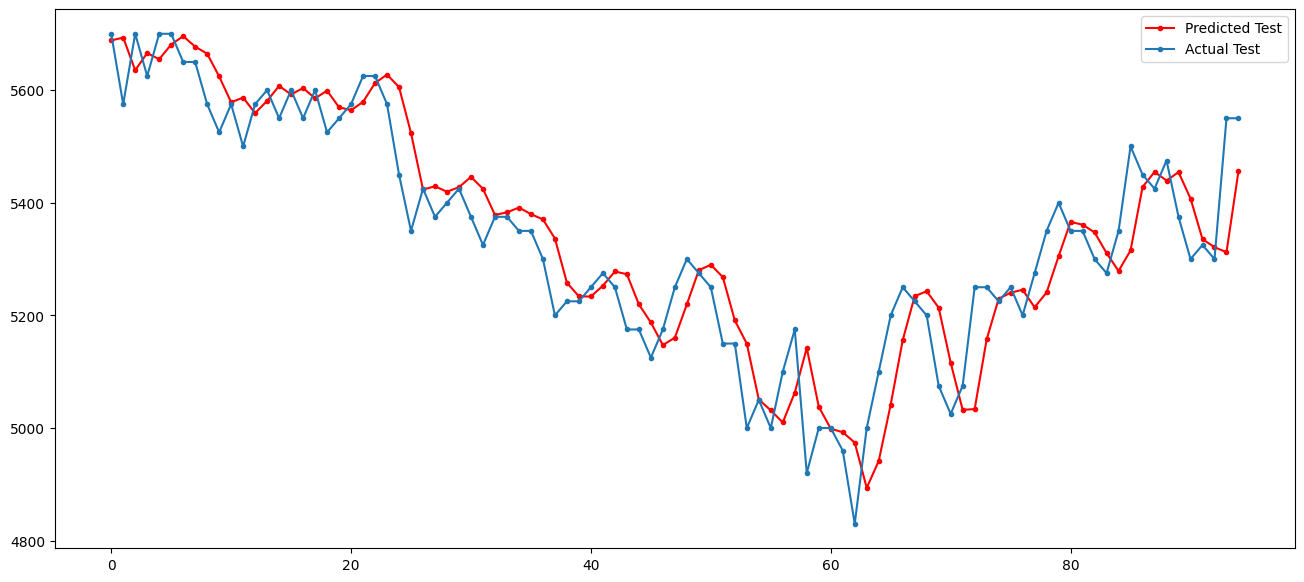

In [ ]:
plt.figure(figsize=(16,7))

plt.plot(predictions, 'r', marker='.', label='Predicted Test')
plt.plot(y_test, marker='.', label='Actual Test')

plt.legend()
plt.show()

In [ ]:

# Ambil 30 hari terakhir sebagai last_sequence
last_sequence = scaled_data_test[-30:]

# Inisialisasi tanggal terakhir
last_date = datetime.strptime(end_date, '%Y-%m-%d')
last_date = last_date - timedelta(days=1)
last_date = last_date.date()

# Lakukan prediksi untuk 30 hari ke depan
future_predictions = []
future_dates = []
future_days = 22

for _ in range(future_days):
    next_date = last_date + timedelta(days=1)

    # Lewati hari Sabtu dan Minggu (indeks 5 atau 6)
    while next_date.weekday() >= 5:
        next_date += timedelta(days=1)

    reshaped_sequence = last_sequence.reshape(1, last_sequence.shape[0], 1)

    # Prediksi harga untuk satu hari ke depan menggunakan model_saved
    prediction = model.predict(reshaped_sequence)[0][0]
    future_predictions.append(prediction)
    future_dates.append(next_date)

    # Perbarui urutan terakhir dengan menambahkan prediksi baru dan menghapus harga pertama dalam urutan
    last_sequence = np.append(last_sequence[1:], prediction)

    last_date = next_date

# Lakukan inversi scaling pada prediksi
future_predictions = np.array(future_predictions).reshape(-1, 1)
future_predictions = scaler.inverse_transform(future_predictions)

# Buat dataframe dari hasil prediksi
predicted_df = pd.DataFrame({'Tanggal': future_dates, 'Prediksi_Harga': future_predictions.flatten()})

# Tampilkan hasil prediksi
print(predicted_df)


1/1 [==============================] - 0s 30ms/step
       Tanggal  Prediksi_Harga
0   2023-12-18     5527.798828
1   2023-12-19     5537.843750
2   2023-12-20     5534.683594
3   2023-12-21     5529.777832
4   2023-12-22     5526.263184
5   2023-12-25     5525.053223
6   2023-12-26     5526.209961
7   2023-12-27     5529.341797
8   2023-12-28     5533.890625
9   2023-12-29     5539.309570
10  2024-01-01     5545.150391
11  2024-01-02     5551.095215
12  2024-01-03     5556.952148
13  2024-01-04     5562.625488
14  2024-01-05     5568.089844
15  2024-01-08     5573.357422
16  2024-01-09     5578.462891
17  2024-01-10     5583.439453
18  2024-01-11     5588.316406
19  2024-01-12     5593.113281
20  2024-01-15     5597.838867
21  2024-01-16     5602.493652


#Save Data

In [ ]:
predicted_df['Prediksi_Harga']=predicted_df['Prediksi_Harga'].round(decimals=0)

In [ ]:
predicted_df.to_csv('BCA.csv')

In [ ]:
test_data = close_prices[training_data_len:]
test_data

Date
2023-08-03    9250.0
2023-08-04    9150.0
2023-08-07    9275.0
2023-08-08    9200.0
2023-08-09    9400.0
               ...  
2023-12-11    8750.0
2023-12-12    8700.0
2023-12-13    8675.0
2023-12-14    9050.0
2023-12-15    9225.0
Name: Close, Length: 95, dtype: float64

In [ ]:
df_test_bri = pd.DataFrame(test_data)
df_test_bri['Testing'] = predictions.round(decimals=0)
df_test_bri

,Close,Testing
Date,,
2023-08-03,9250.0,9190.0
2023-08-04,9150.0,9235.0
2023-08-07,9275.0,9164.0
2023-08-08,9200.0,9231.0
2023-08-09,9400.0,9207.0
...,...,...
2023-12-11,8750.0,8783.0
2023-12-12,8700.0,8767.0
2023-12-13,8675.0,8735.0


In [ ]:
df_test_bri.to_csv('BCA_testing.csv')

In [ ]:
df_train_bri = close_prices[: training_data_len]
df_train_bri

Date
2022-01-03    7325.0
2022-01-04    7400.0
2022-01-05    7450.0
2022-01-06    7475.0
2022-01-07    7650.0
               ...  
2023-07-27    9225.0
2023-07-28    9125.0
2023-07-31    9125.0
2023-08-01    9125.0
2023-08-02    9200.0
Name: Close, Length: 382, dtype: float64

In [ ]:
df_train_bri.to_csv('BCA_train.csv')